#Analyse de conversations patient-thérapeute sur la santé mentale
Kaggle : https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations?resource=download

## Etape 1 : Exploration du jeu de données

### Imports

In [12]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('train.csv')
df = df.dropna(subset=['Context', 'Response']).reset_index(drop=True) #supression ligne vide et reindexage
print("Nb lignes : ", len(df))
df.head(5)

Nb lignes :  3508


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


### Tableau statistique récapitulatif

In [ ]:
import pandas as pd

nbPatients = df['Context'].nunique()
nbTherapeutes = df['Response'].nunique()
nbReponseMoyenne = df.groupby('Context')['Response'].nunique().mean()
nbReponseMax = df.groupby('Context')['Response'].nunique().max()
nbReponseMin = df.groupby('Context')['Response'].nunique().min()

recap = pd.DataFrame({
    'Nb': [
        'Nb patients',
        'Nb thérapeutes',
        'Nb réponses moyen',
        'Nb réponses max',
        'Nb réponses min'
    ],
    'Valeur': [
        nbPatients,
        nbTherapeutes,
        round(nbReponseMoyenne, 2),
        nbReponseMax,
        nbReponseMin
    ]
})

recap.style.set_caption("Tableau recapitulatif")

,Métrique,Valeur
0,Nb patients,995.00
1,Nb thérapeutes,2479.00
2,Nb réponses moyen,2.76
3,Nb réponses max,47.00
4,Nb réponses min,1.00


### Dictionnaire lexical

Identification des mots :

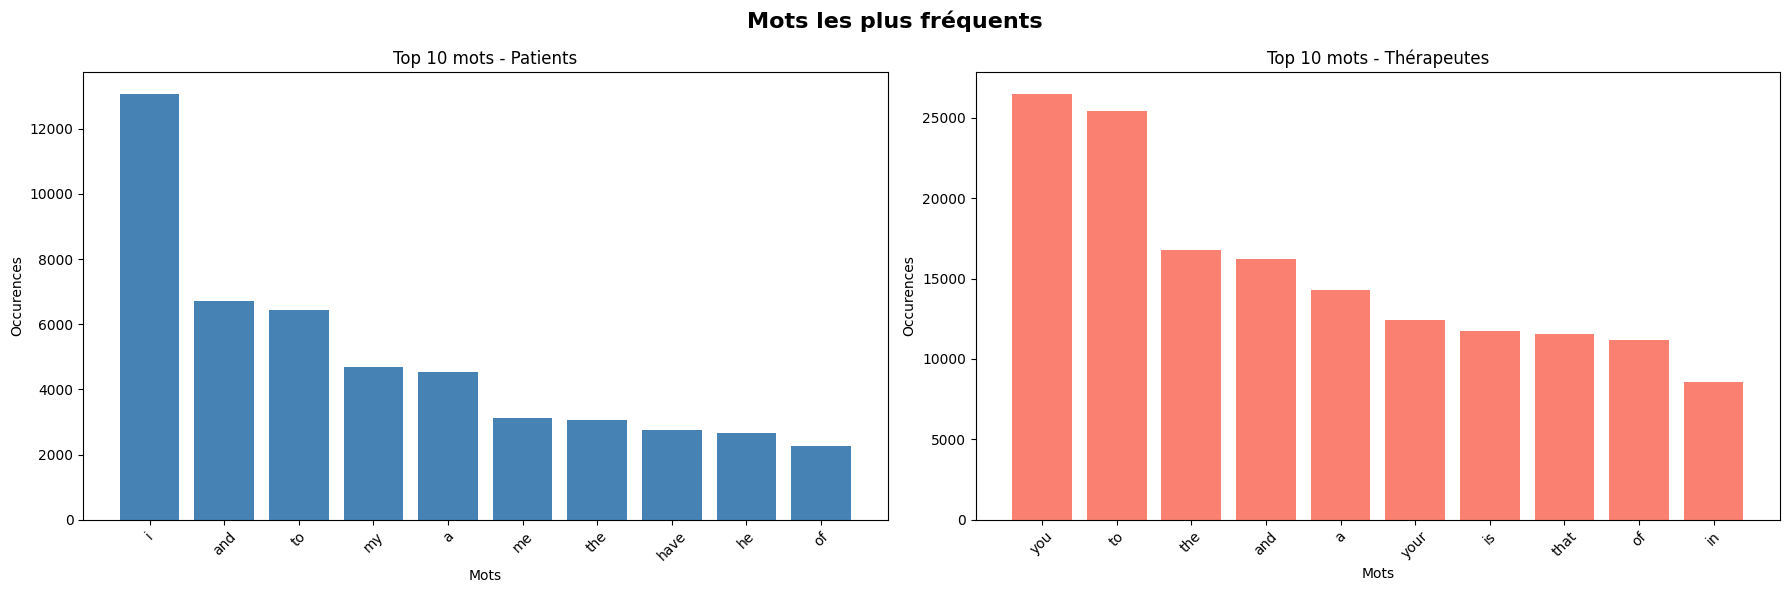

In [ ]:
df_patient = df['Context']
df_therapeute = df['Response']


# nettoyage
def clean(df):
    mots = []
    for phrase in df:
        phrase = re.sub(r'[^\w\s]', '', phrase)
        phrase = phrase.lower()
        mots.extend(phrase.split())
    return mots

#patient
df_mots = pd.DataFrame(clean(df_patient), columns = ['mots'])
df_patient_occurence = df_mots['mots'].value_counts().reset_index()
df_patient_occurence.columns = ['mots', 'occurences']

#therapeute
df_mots = pd.DataFrame(clean(df_therapeute), columns = ['mots'])
df_therapeute_occurence = df_mots['mots'].value_counts().reset_index()
df_therapeute_occurence.columns = ['mots', 'occurences']

top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histo patients
df_top_patient = df_patient_occurence.nlargest(top_n, 'occurences')
axes[0].bar(df_top_patient['mots'], df_top_patient['occurences'], color='purple')
axes[0].set_title(f'Top {top_n} mots - Patients')
axes[0].set_xlabel('Mots')
axes[0].set_ylabel('Occurences')
axes[0].tick_params(axis='x', rotation=45)

# Histo thérapeutes
df_top_therapeute = df_therapeute_occurence.nlargest(top_n, 'occurences')
axes[1].bar(df_top_therapeute['mots'], df_top_therapeute['occurences'], color='pink')
axes[1].set_title(f'Top {top_n} mots - Thérapeutes')
axes[1].set_xlabel('Mots')
axes[1].set_ylabel('Occurences')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Mots les plus fréquents', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Identification des mots du lexique de l'emotion

In [ ]:
#lecture du lexicon NRC
lexicon = pd.read_csv('NRC-Emotion-Lexicon-Wordlevel.txt',
                  sep='\t', header=None,
                  names=['word', 'emotion', 'level'])

#retrait de la colonne 'level' du NRC
lexicon = lexicon[lexicon['level']==1].drop(columns=['level'])
lexicon = lexicon.reset_index(drop=True)

#tableau d'occurence des mots uniquement liés à une émotion
df_patient_occurence = df_patient_occurence[df_patient_occurence['mots'].isin(lexicon['word'].values)]
df_patient_occurence = df_patient_occurence.merge(lexicon,
                                               left_on='mots',
                                               right_on='word',
                                               how='left').drop(columns=['word'])

df_therapeute_occurence = df_therapeute_occurence[df_therapeute_occurence['mots'].isin(lexicon['word'].values)]
df_therapeute_occurence = df_therapeute_occurence.merge(lexicon,
                                               left_on='mots',
                                               right_on='word',
                                               how='left').drop(columns=['word'])


10

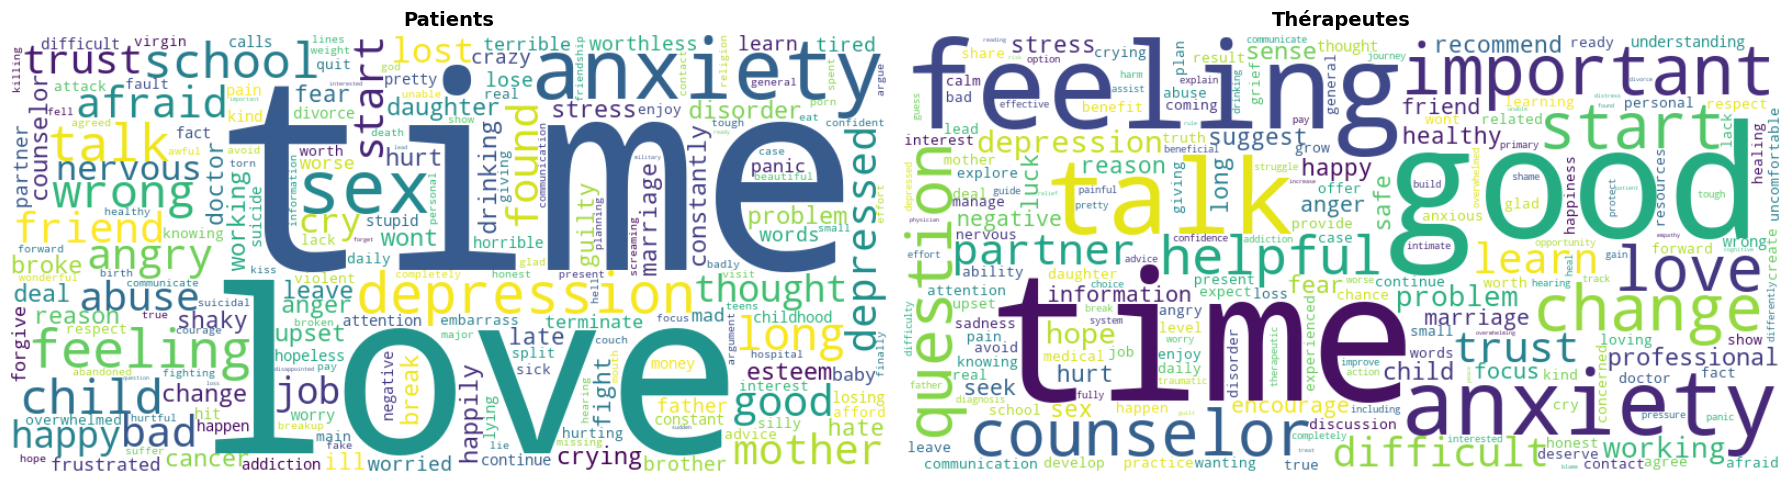

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# creer un dictionnaire mots-occurences
freq_dict_p = dict(zip(df_patient_occurence['mots'], df_patient_occurence['occurences']))
freq_dict_t = dict(zip(df_therapeute_occurence['mots'], df_therapeute_occurence['occurences']))


wc_p = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(freq_dict_p)

wc_t = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(freq_dict_t)

#affichage

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# wordcloud patients
axes[0].imshow(wc_p, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Patients', fontsize=14, fontweight='bold')

# wordcloud thérapeutes
axes[1].imshow(wc_t, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Thérapeutes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

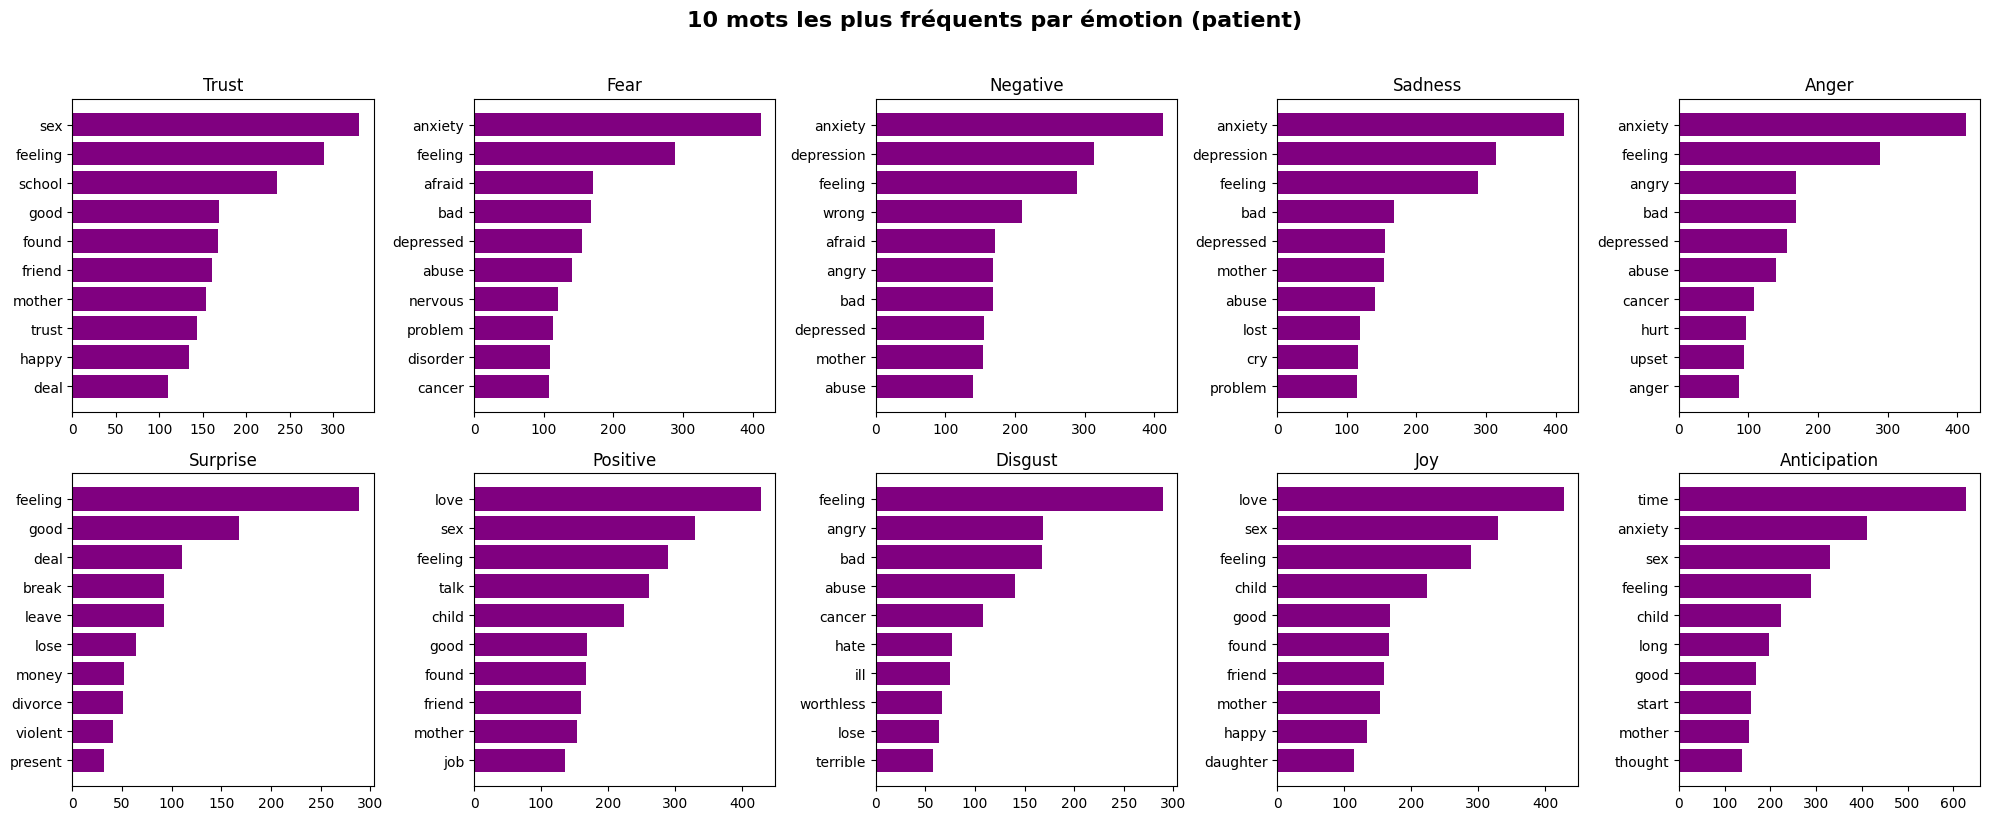

In [101]:
emotions = lexicon['emotion'].unique()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, emotion in enumerate(emotions):
    # 5 mots les plus frequents
    df_emotion = df_patient_occurence[df_patient_occurence['emotion'] == emotion].nlargest(10, 'occurences')
    
    axes[i].barh(df_emotion['mots'], df_emotion['occurences'], color='purple')
    axes[i].set_title(emotion.capitalize())
    axes[i].invert_yaxis() 

plt.suptitle('10 mots les plus fréquents par émotion (patient)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## TF-IDF

### Objectif : 
Contrebalancer les mots de fortes occurences qui sont génériques et ne donnent que trop peu d'information (ex: "I", "you", "am", etc...)
[+info][def]

[def]: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html#sklearn.feature_extraction.text.TfidfTransformer

**Formule TF-IDF :**

$$tf\text{-}idf(t, d) = tf(t, d) \times idf(t)$$

avec $t$ un terme et $d$ un document.

$$idf(t) = \log\left(\frac{n}{df(t)}\right) + 1$$

avec $n$ le nombre de documents et $df(t)$ le nb de documents contenant $t$ sur le nb de documents total $n $.

In [74]:
from sklearn.cluster import KMeans


In [103]:
tfidf_context = TfidfVectorizer(stop_words='english')
tfidf_response = TfidfVectorizer(stop_words='english')

# retourne une matrice termes-documents pondérée par le TF-IDF
matrice_context = tfidf_context.fit_transform(df['Context'].unique())
matrice_response = tfidf_response.fit_transform(df['Response'].unique())

# cluster
k = 5
km_context = KMeans(n_clusters=k, random_state=42)
km_context.fit(matrice_context)

km_response = KMeans(n_clusters=k, random_state=42)
km_response.fit(matrice_response)

# Affichage
terms_context = tfidf_context.get_feature_names_out()
terms_response = tfidf_response.get_feature_names_out()


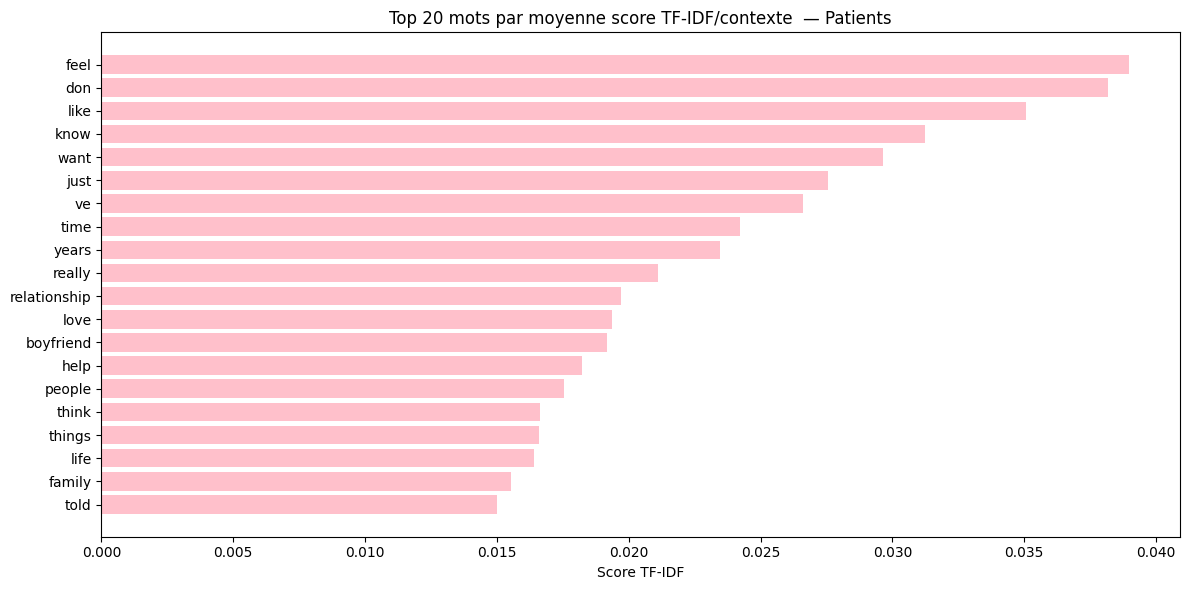

In [ ]:
df_tfidf_context = pd.DataFrame(
    matrice_context.toarray(),
    columns=terms_context
)

df_tfidf_response = pd.DataFrame(
    matrice_response.toarray(),
    columns=terms_response
)


scores_context = df_tfidf_context.mean().sort_values(ascending=False)
scores_response = df_tfidf_response.mean().sort_values(ascending=False)
top_tfidf_context = scores_context.head(20)
top_tfidf_response = scores_response.head(20)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.figure(figsize=(12, 6))
plt.barh(top_tfidf.index, top_tfidf.values, color='pink')
plt.gca().invert_yaxis()
plt.title('Top 20 mots par moyenne score TF-IDF/contexte  — Patients')
plt.xlabel('Score TF-IDF')
plt.tight_layout()
plt.show()


## clusters de word embedding

In [70]:
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

ModuleNotFoundError: No module named 'sentence_transformers'

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
contexts = df['Context'].unique().tolist()
embeddings = model.encode(contexts, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
# Réduction de dimension
reducer = umap.UMAP(n_components=10, random_state=42)
embeddings_reduced = reducer.fit_transform(embeddings)

# Clustering
clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
labels = clusterer.fit_predict(embeddings_reduced)

# Affichage
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Nb de clusters trouvés : {n_clusters}")
print(f"Outliers : {list(labels).count(-1)}")

for i in sorted(set(labels)):
    indices = np.where(labels == i)[0]
    label = "Outliers" if i == -1 else f"Cluster {i} ({len(indices)} docs)"
    print(f"\n{label}:")
    for idx in indices[:3]:
        print(" -", contexts[idx][:120])

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Nb de clusters trouvés : 5
Outliers : 384

Outliers:
 - A few years ago I was making love to my wife when for no known reason I lost my erection,    Now I'm In my early 30s and
 - I am going through a divorce. He is extremely angry. He refuses to physically assist me with our teenager daughter. I ha
 - My girlfriend just quit drinking and she became really depressed. She told me that she wants to move. What can I do to h

Cluster 0 (291 docs):
 - I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worth
 - I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime ins
 - I have been feeling more and more down for over a month. I have started having trouble sleeping due to panic attacks, bu

Cluster 1 (72 docs):
 - She has trouble falling and staying asleep and she's always either extremely hungry or not hungry at all. She also gets 
 - My mother is combative with me 

## En utilisant un modèle d’extraction de sujet LDA

In [ ]:
!pip install pyldavis==3.4.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.2 MB/s eta 0:00:00


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.lda_model
import re

# 1. Nettoyage
def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

contexts_clean = [clean(c) for c in df['Context'].unique()]

# 2. Vectorisation
vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(contexts_clean)

# 3. LDA
lda = LatentDirichletAllocation(
    n_components=8,
    max_iter=20,
    learning_method='batch',
    random_state=42
)
lda.fit(X)

# 4. Affichage topics (texte)
terms = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [terms[j] for j in topic.argsort()[-10:]]
    print(f"Topic {i}: {top_words}")

# 5. pyLDAvis
!pip install pyldavis -q

pyLDAvis.enable_notebook()  # activation pour Colab/Jupyter

vis = pyLDAvis.lda_model.prepare(
    lda,        # modèle LDA
    X,          # matrice document-terme
    vectorizer, # vectorizer fitted
    mds='pcoa', # réduction de dimension : 'pcoa' ou 'tsne'
    sort_topics=False  # garde l'ordre original des topics
)

pyLDAvis.display(vis)

# 6. Export HTML (interactif)
pyLDAvis.save_html(vis, "lda_visualization.html")
print("✅ Visualisation sauvegardée dans lda_visualization.html")

# 7. Téléchargement (Colab)
from google.colab import files
files.download("lda_visualization.html")

Topic 0: ['boyfriend', 'love', 'want', 'just', 'feel', 'like', 'dont know', 'im', 'know', 'dont']
Topic 1: ['anxiety', 'make', 'know', 'ive', 'really', 'want', 'like', 'feel', 'dont', 'im']
Topic 2: ['having', 'years', 'disorder', 'told', 'therapist', 'im', 'time', 'anxiety', 'night', 'child']
Topic 3: ['parents', 'says', 'hes', 'wanted', 'help', 'dont', 'love', 'just', 'want', 'im']
Topic 4: ['husband', 'married', 'time', 'feel', 'got', 'hes', 'ive', 'work', 'im', 'years']
Topic 5: ['time', 'told', 'husband', 'says', 'help', 'years', 'like', 'just', 'im', 'things']
Topic 6: ['afraid', 'just', 'dont', 'want', 'feel like', 'relationship', 'people', 'like', 'im', 'feel']
Topic 7: ['family', 'ive', 'left', 'like', 'help', 'life', 'feel', 'im', 'years', 'time']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Visualisation sauvegardée dans lda_visualization.html


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag